In [1]:
import numpy as np
import matplotlib.pyplot as plt
from datataking import search_datadict_miyamura
from Analysis import WaveformAnalysisMulti, fourier_tr_padding, lowpass, start_stop#, probe_resonator_fit
import time as T

cd = "CDK174"
data_path = f"D:\\K_Sunada\\result\\{cd}"

readout_lo_freq = 9.47

# symmetrical shape

In [2]:
name_dict = dict(
    data1 = dict(amp=0.2, date="2025-02-20", acquire_time="101745", params=dict(fit_start=250, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False)), 
    data2 = dict(amp=0.4, date="2025-02-20", acquire_time="103916", params=dict(fit_start=220, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False, skip=[20])), 
    data4 = dict(amp=0.5, date="2025-02-20", acquire_time="105330", params=dict(fit_start=180, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    data5 = dict(amp=0.6, date="2025-02-20", acquire_time="110125", params=dict(fit_start=180, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    data6 = dict(amp=0.7, date="2025-02-20", acquire_time="110727", params=dict(fit_start=150, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    # data8 = dict(amp=0.9, date="2025-02-18", acquire_time="085557", params=dict(fit_start=120, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
    # data9 = dict(amp=0.9, date="2025-02-17", acquire_time="132138", params=dict(fit_start=100, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=False, skip=[18, 19, 20])), 
    # data10 = dict(amp=1.0, date="2025-02-18", acquire_time="090004", params=dict(fit_start=80, fp=0.01, fs=0.05, gpass=1, gstop=90, plot=True)), 
)

# Generating Control Pulses

0.2 2025-02-20 101745
0.4 2025-02-20 103916
0.5 2025-02-20 105330
0.6 2025-02-20 110125
0.7 2025-02-20 110727


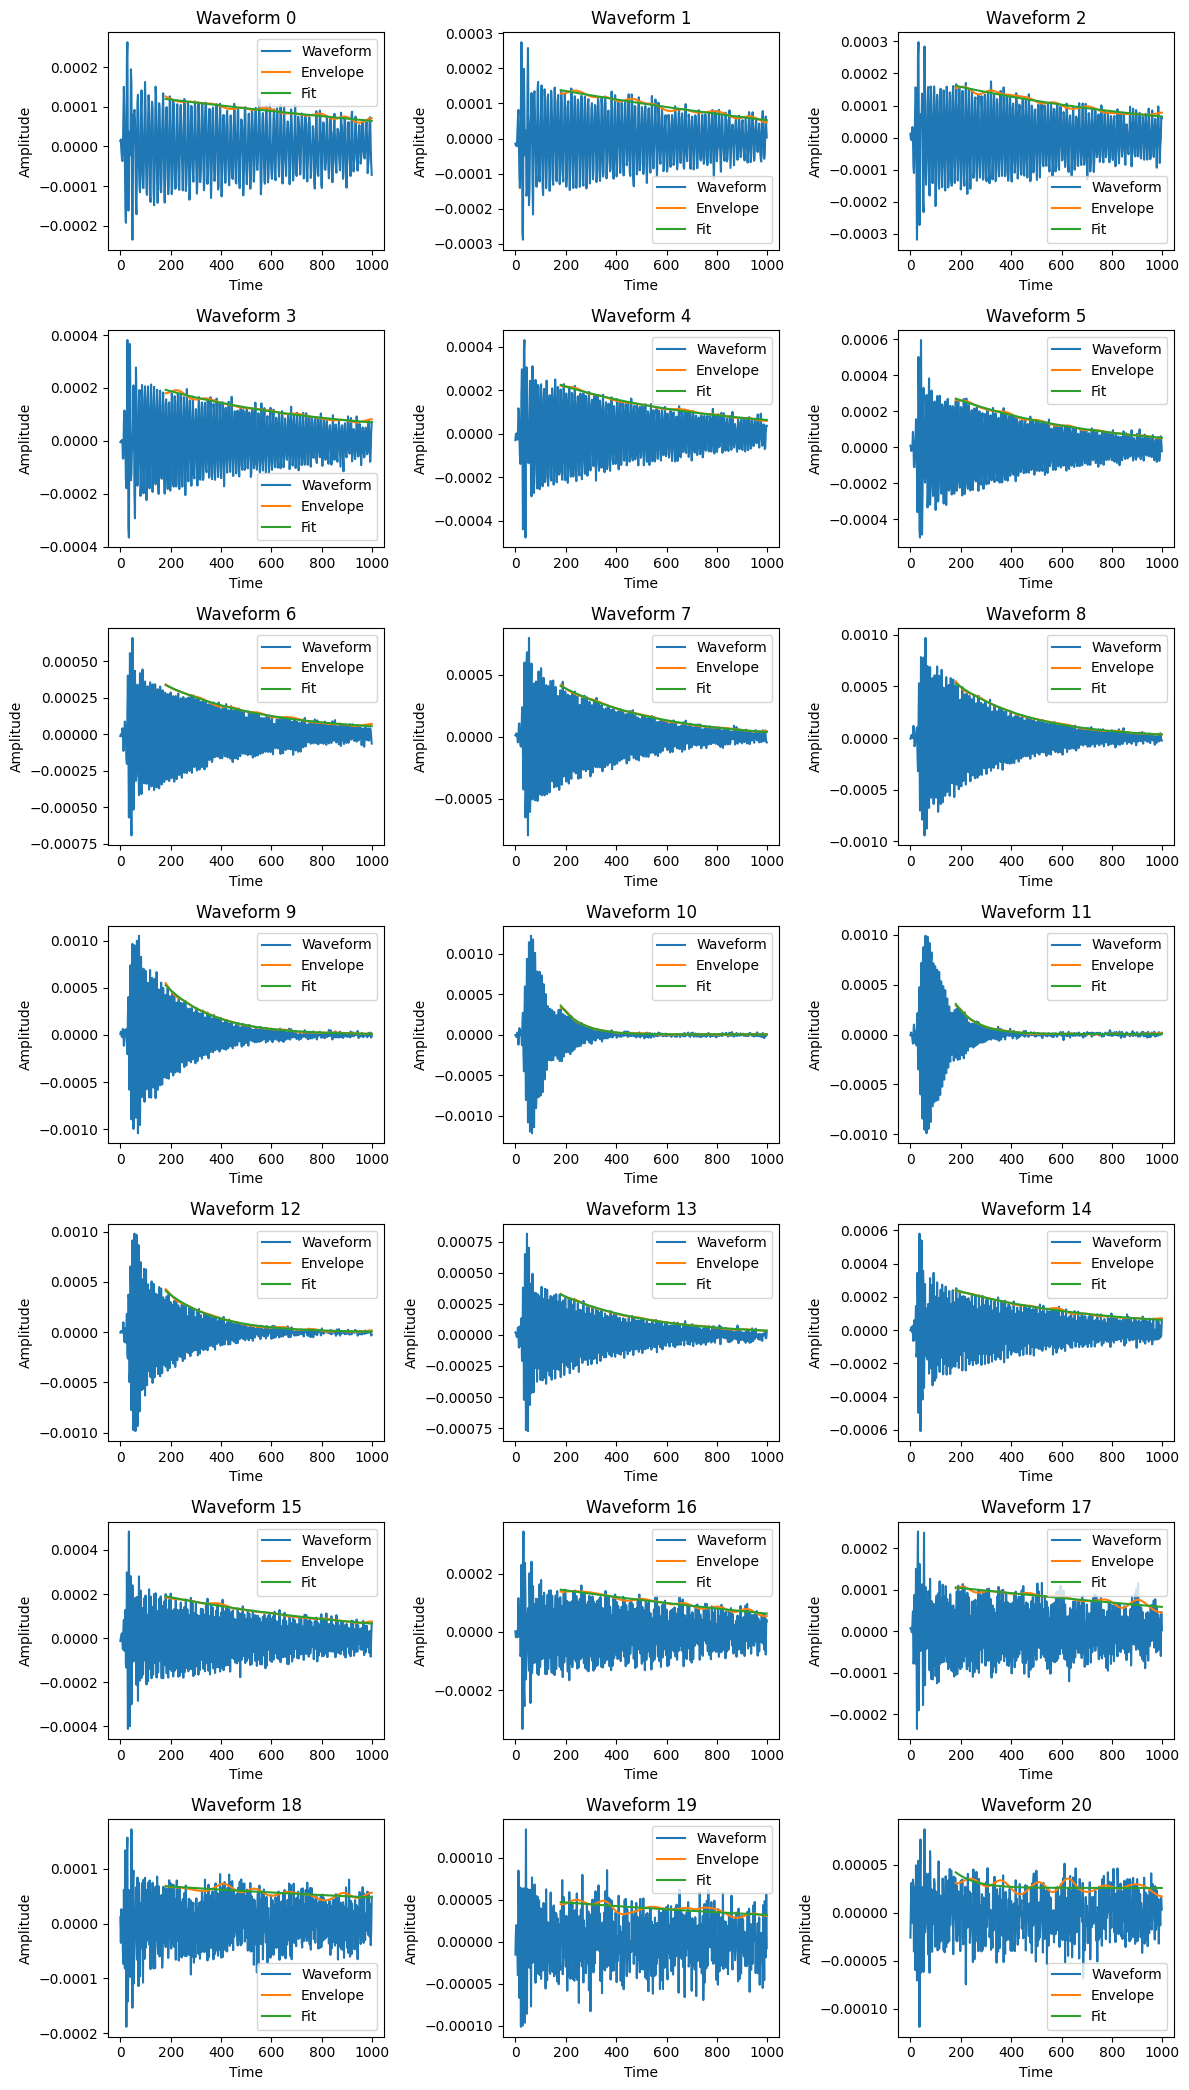

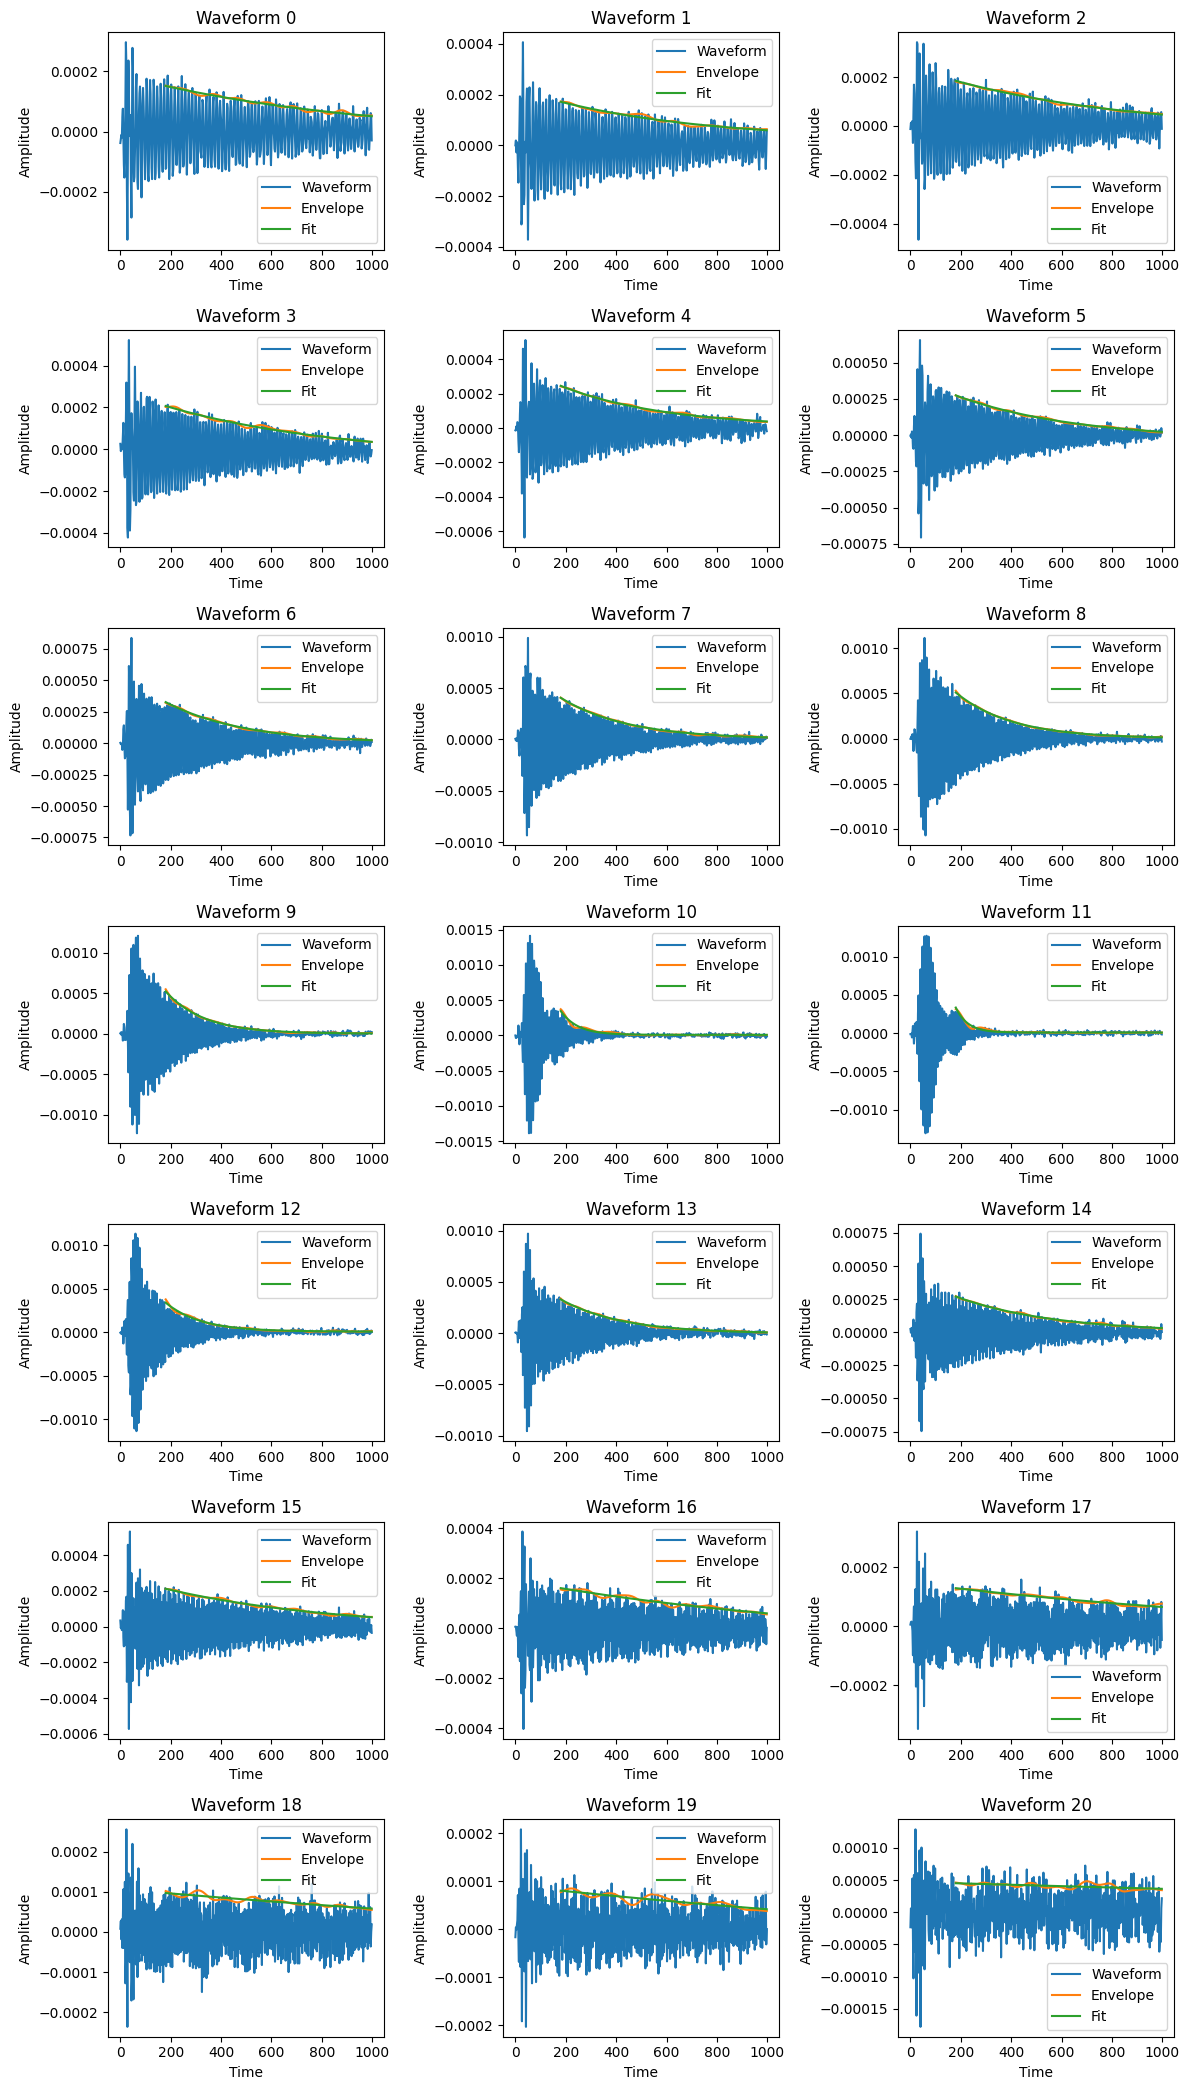

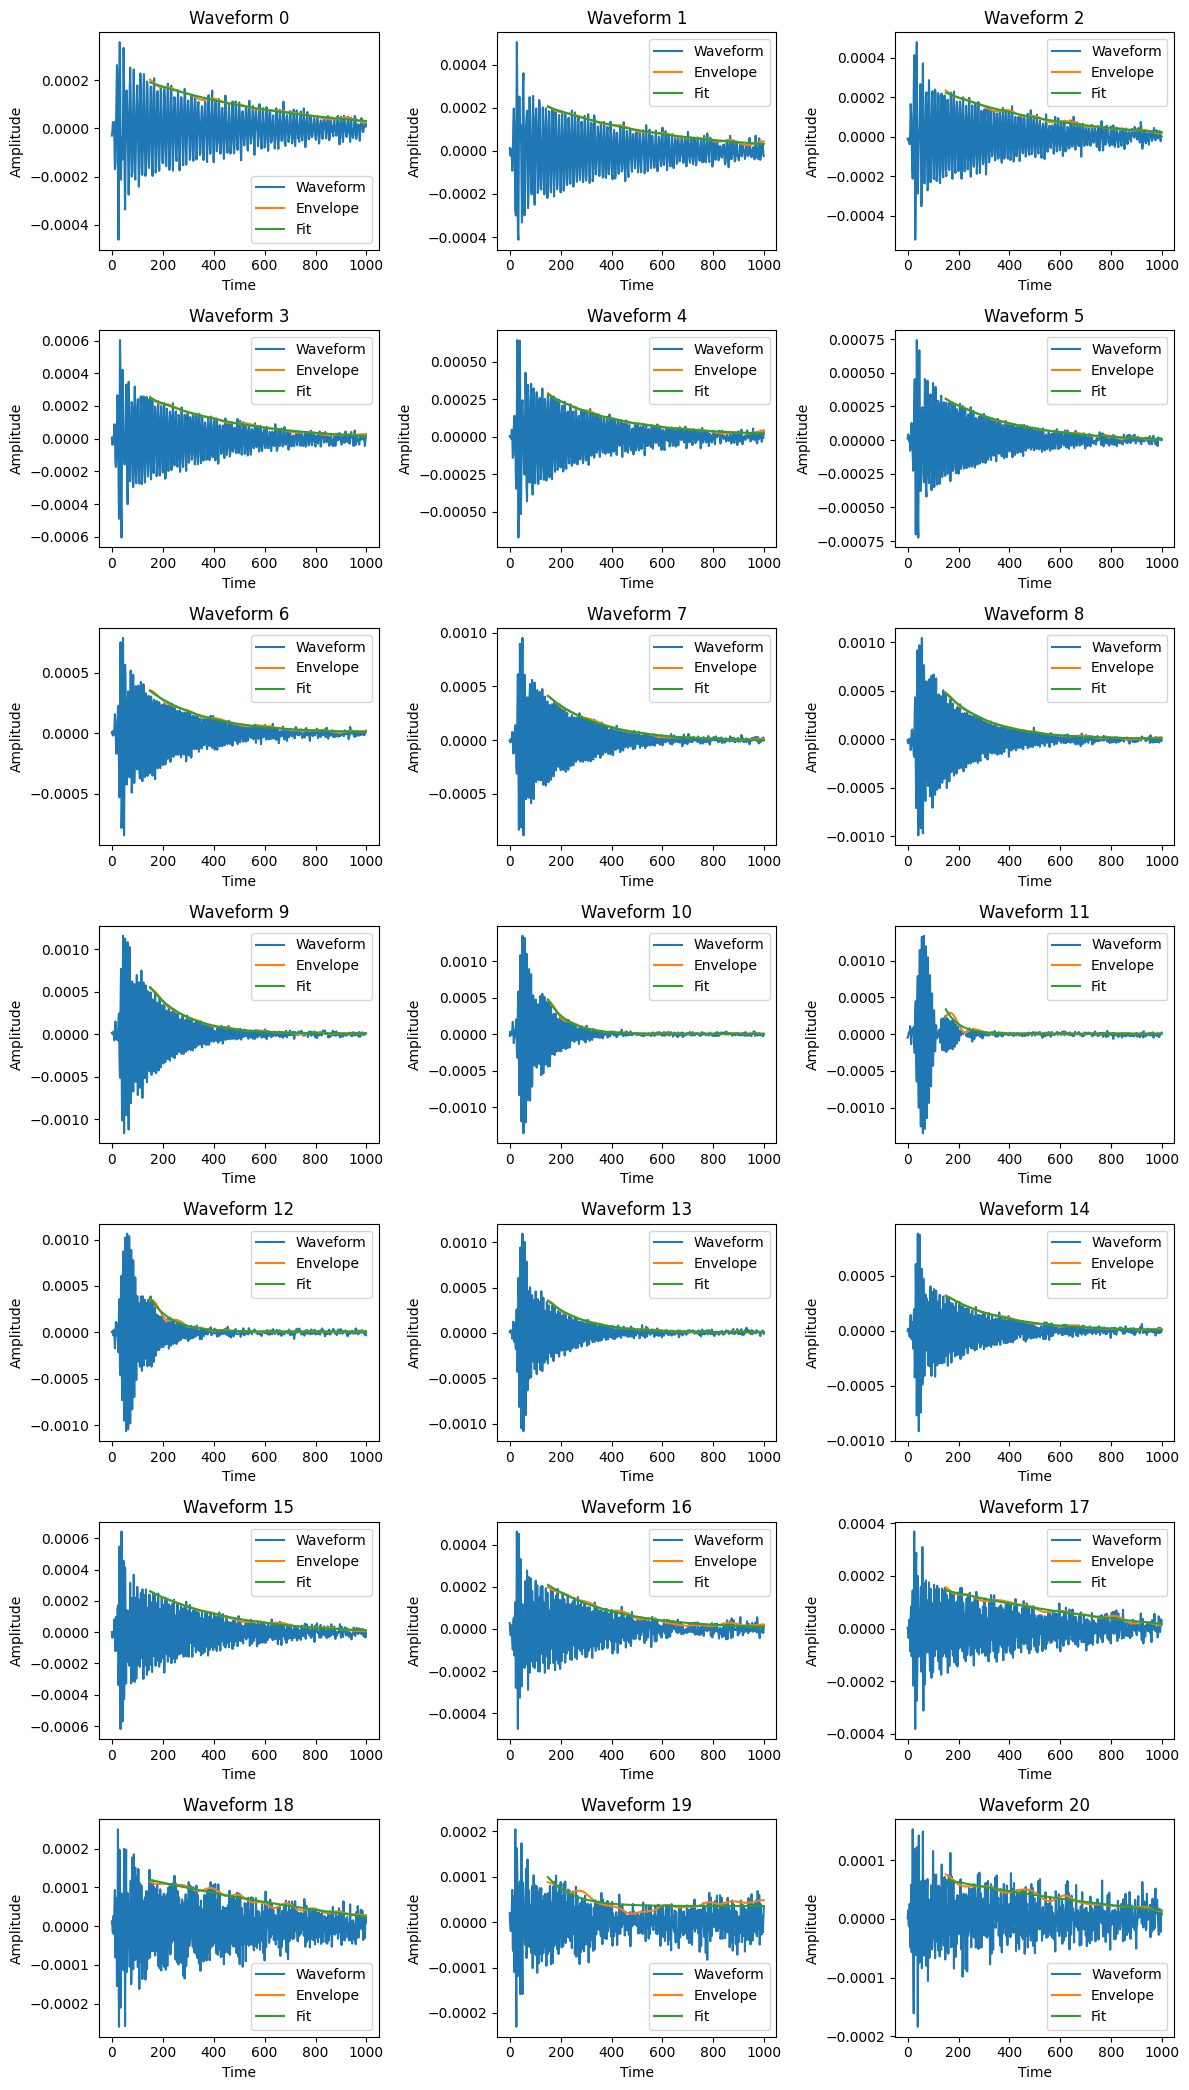

In [3]:
dataobj = WaveformAnalysisMulti(name_dict, data_path)
dataobj.generate_results(readout_lo_freq)

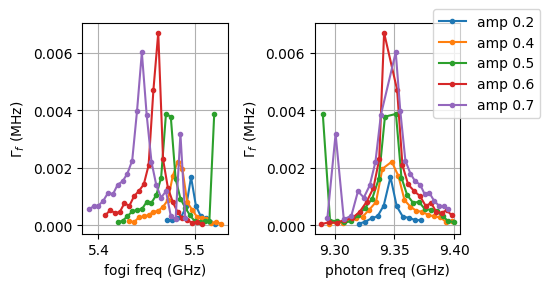

{'a0': 0, 'a2': 0.013102909058353207, 'a4': 4.318767565791859e-13, 'a6': 7.207789920471441e-12, 'a8': 4.8183679268731794e-14, 'a10': 2.844391389089651e-13}


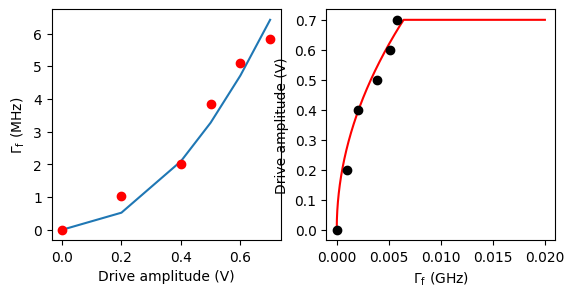

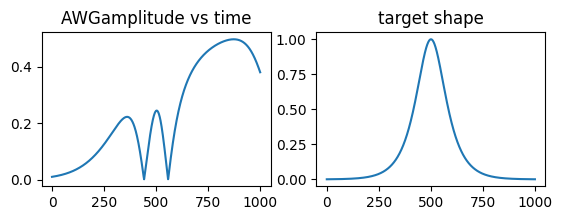

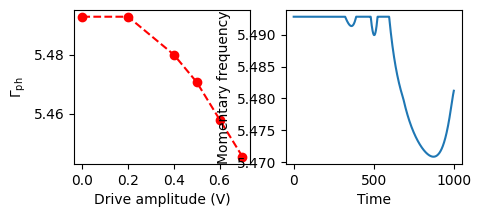

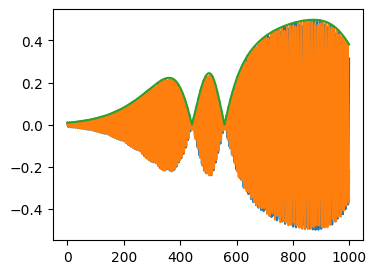

In [4]:
const = 2.5e-3 * 2 * np.pi
duration = 1000
target_freq = 9.35

# plot decay rates
dataobj.plot_decayrates()

control_pulse = dataobj.generate_control_pulse(5.37, target_freq, duration, const=const, form="sech_2", tr=False)[0]

## save

In [ ]:
from plottr.data.datadict_storage import DataDict, DDH5Writer
import time as T
forms = ["sech_0", "sech_1", "sech_2", "sech_3"] 

for form in forms:
    for target_freq in [9.35]:
        control_pulse, control_envelope = dataobj.generate_control_pulse(
            5.37, target_freq, duration, const=const, form=form, plot=False, tr=False
        )

        note = f"""
        form : {form}
        const : {const / 2 / np.pi}
        duration : {duration}
        target frequency : {target_freq} GHz
        """

        data = DataDict(
            time=dict(unit="ns"),
            control_pulse=dict(axes=["time"]),
            control_envelope=dict(axes=["time"])
        )
        data.validate()

        save_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}"

        with DDH5Writer(data, save_path, name="Control_Pulse") as writer:
            writer.add_tag(["control_pulse", cd, form])
            writer.save_text("target_shape.md", note)
            writer.add_data(
                time=np.arange(len(control_pulse)),
                control_pulse=control_pulse,
                control_envelope=control_envelope
            )
        T.sleep(1)


NameError: name 'dataobj' is not defined

# Photon shaping analysis

In [2]:
from Analysis import SechPhotonAnalysis
import numpy as np
import matplotlib.pyplot as plt
cd = "CDK174"

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


Form: sech_0, Symmetry: 0.7043829466000439, Overlap: 0.9917243577733493
Form: sech_1, Symmetry: 0.2234736828871147, Overlap: 0.9692646501971888
Form: sech_2, Symmetry: 0.3202752702023265, Overlap: 0.9592297707832645
Form: sech_3, Symmetry: 0.32289213194116295, Overlap: 0.9709858428066369


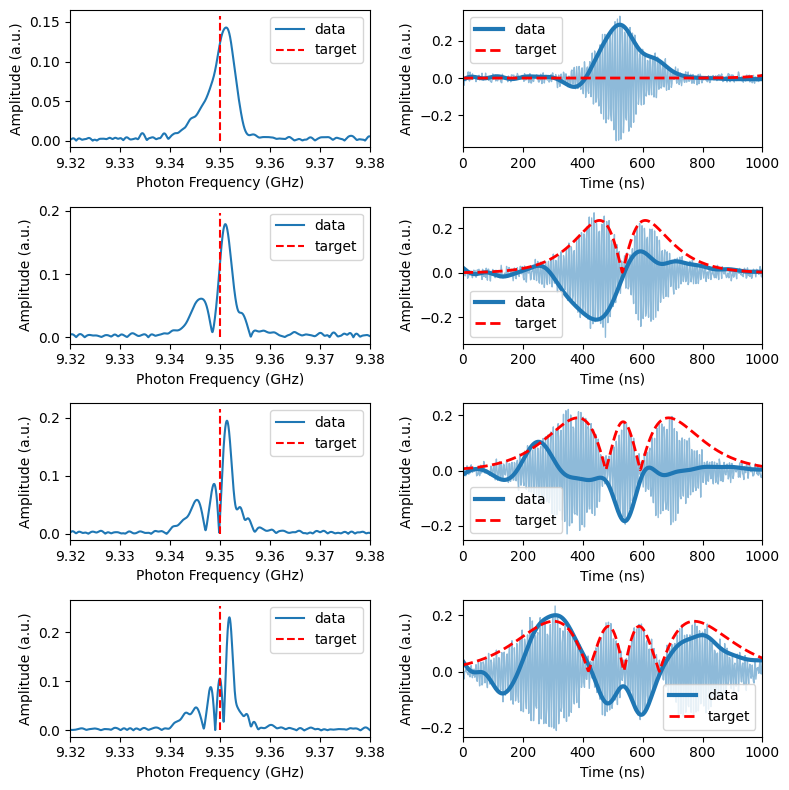

In [3]:
data_path = f"D:\\K_Sunada\\result\\{cd}"
readout_lo_freq = 9.47
duration = 1000
passing_band = 0.01
const = 2.5e-3*2*np.pi

result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-21", acquire_time="105109", form="sech_0"),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-21", acquire_time="105147", form="sech_1"),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-21", acquire_time="105223", form="sech_2"),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-21", acquire_time="105300", form="sech_3"),
}

analyzer = SechPhotonAnalysis(data_path, result_dict, duration, const, readout_lo_freq)
analyzer.analyze_waveforms(passing_band)

phase subtraction

In [4]:
ctrl_pulse_path = f"D:\\K_Sunada\\result\\control_pulses\\{cd}\\"
# analyzer.phase_subtraction_and_pulse_flip(ctrl_pulse_path)

corrected photon shaping

Form: sech_0, Symmetry: 0.8830465036926078, Overlap: 0.9949977439137664
Form: sech_1, Symmetry: 0.6242730493900801, Overlap: 0.9437698278597022
Form: sech_2, Symmetry: 0.5456347738616029, Overlap: 0.9285031718707377
Form: sech_3, Symmetry: 0.4203067788381111, Overlap: 0.9187023952472713


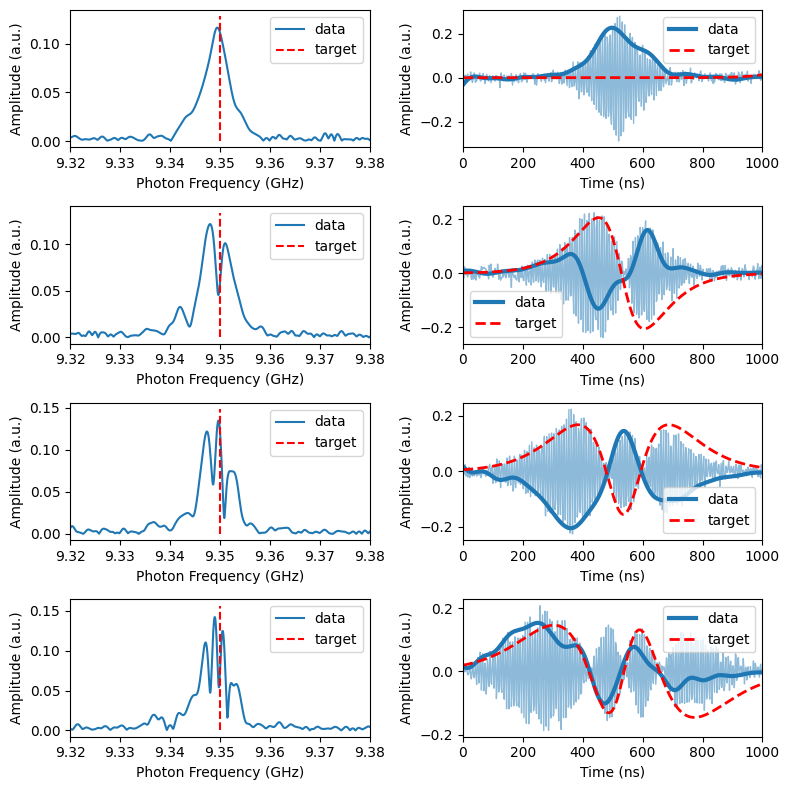

In [5]:
const = 2.5e-3 * 2*np.pi
corrected_result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-21", acquire_time="105455", form="sech_0", center=510),
    "data_sech_1": dict(target_freq=9.35, date="2025-02-21", acquire_time="105532", form="sech_1", center=600),
    "data_sech_2": dict(target_freq=9.35, date="2025-02-21", acquire_time="105609", form="sech_2", center=400),
    "data_sech_3": dict(target_freq=9.35, date="2025-02-21", acquire_time="105645", form="sech_3", center=460),
}
corrected_analyzer = SechPhotonAnalysis(data_path, corrected_result_dict, duration, const, readout_lo_freq)
corrected_analyzer.analyze_waveforms(passing_band, flipped=True)

Form: sech_0, Symmetry: 0.8830465036926078, Overlap: 0.9949977439137664
Form: sech_1, Symmetry: 0.6242730493900801, Overlap: 0.9437698278597022
Form: sech_2, Symmetry: 0.5456347738616029, Overlap: 0.9285031718707377
Form: sech_3, Symmetry: 0.4203067788381111, Overlap: 0.9187023952472713


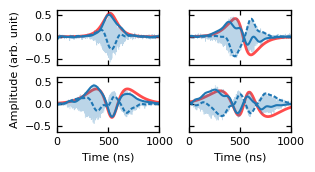

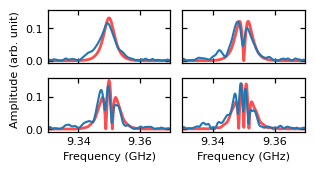

separability: (0.7805981992118796, [0.8361870976862578, 0.782335603643977, 0.7167859704960915, 0.7870841250211918])


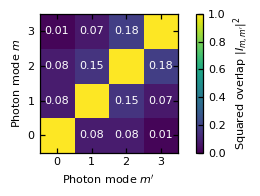

In [8]:
# plt.rcParams.update({
#     'xtick.direction': 'in',
#     'ytick.direction': 'in',
#     'xtick.major.width': 0.9,
#     'ytick.major.width': 0.9,
#     'font.size': 12,
#     'axes.linewidth': 0.9,
#     'xtick.top': True,
#     'xtick.bottom': True,
#     'ytick.left': True,
#     'ytick.right': True,
#     'lines.linewidth': 1,
#     'lines.markersize': 2,
# })

corrected_analyzer.analyze_waveforms_t(0.01, flipped=True, dc=0)
# plt.savefig("photons.pdf")
# plt.savefig("photons.png", bbox_inches='tight')
plt.show()

corrected_analyzer.analyze_waveforms_f(0.01)
# plt.savefig("photon_spectra.pdf")
# plt.savefig("photons.png", bbox_inches='tight')
plt.show()

corrected_analyzer.plot_squaredI_matrix(4)
# plt.savefig("Fig2_c.pdf")
# plt.savefig("Fig3_b.png", bbox_inches='tight')
plt.show()

d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
d:\K_Sunada\.venv\lib\site-packages\matplotlib\cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


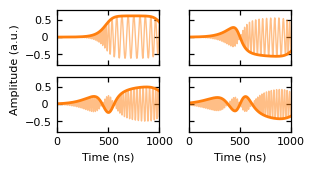

In [ ]:
pulse_dict = dict(
    data0 = dict(target_freq=9.35, date="2025-02-21", acquire_time="105407"),
    data1 = dict(target_freq=9.35, date="2025-02-21", acquire_time="105408"),
    data2 = dict(target_freq=9.35, date="2025-02-21", acquire_time="105409"),
    data3 = dict(target_freq=9.35, date="2025-02-21", acquire_time="105410"),
)
dc = 0.07

fig, axes = plt.subplots(2, 2, figsize=(3.2, 1.8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (k, v) in enumerate(pulse_dict.items()):
    if i >= 4:
        break

    ax = axes[i]
    target_freq = v["target_freq"]

    _, datadict = search_datadict_miyamura(ctrl_pulse_path, v["date"], acquire_time=v["acquire_time"])
    time, waveform, envelope = datadict["time"]["values"].ravel(), datadict["control_pulse"]["values"].ravel(), datadict["control_envelope"]["values"].ravel()

    waveform = waveform*np.exp(-1j*2*np.pi*dc*time)
    ax.plot(time, 1 * waveform, "tab:orange", lw=1, alpha=0.5)
    ax.plot(time, 1 * envelope, "tab:orange", "--", lw=2)


    # ax.label_outer()
    ax.set_xlim(0, 1000)
    ax.set_ylim(-0.8, 0.8)
    if i in [0, 2]:
        ax.set_yticks([-0.5, 0, 0.5])
        ax.set_yticklabels(["−0.5", " 0 ", "0.5"]) 
    if i in [2, 3]:
        ax.set_xlabel("Time (ns)")

fig.text(0.04, 0.6, "Amplitude (a.u.)", va="center", rotation="vertical")

# handles = [
#     plt.Line2D([], [], color="tab:orange", lw=3, label="data"),
#     plt.Line2D([], [], color="r", lw=2, linestyle="--", label="envelope")
# ]
# fig.legend(handles=handles, loc="upper center", ncol=2)
plt.subplots_adjust(wspace=0.01, hspace=0.01)
plt.tight_layout(rect=[0.05, 0.02, 1, 1])

plt.rcParams['xtick.direction'] = 'in'#x軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['ytick.direction'] = 'in'#y軸の目盛線が内向き('in')か外向き('out')か双方向か('inout')
plt.rcParams['xtick.major.width'] = 0.9#x軸主目盛り線の線幅
plt.rcParams['ytick.major.width'] = 0.9#y軸主目盛り線の線幅
plt.rcParams['font.size'] = 8 #フォントの大きさ
plt.rcParams['axes.linewidth'] = 0.9# 軸の線幅edge linewidth。囲みの太さ
plt.rcParams['xtick.top'] = True
plt.rcParams['xtick.bottom'] = True
plt.rcParams['ytick.left'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['lines.linewidth'] = 1
plt.rcParams['lines.markersize'] = 2.
# plt.savefig("fogis.pdf")
plt.show()

fogi pulse generation for absoption

Saved Recieve_Pulse for data_sech_0 at D:\K_Sunada\result\control_pulses\CDK174\
Saved Recieve_Pulse for data_sech_1 at D:\K_Sunada\result\control_pulses\CDK174\
Saved Recieve_Pulse for data_sech_2 at D:\K_Sunada\result\control_pulses\CDK174\
Saved Recieve_Pulse for data_sech_3 at D:\K_Sunada\result\control_pulses\CDK174\


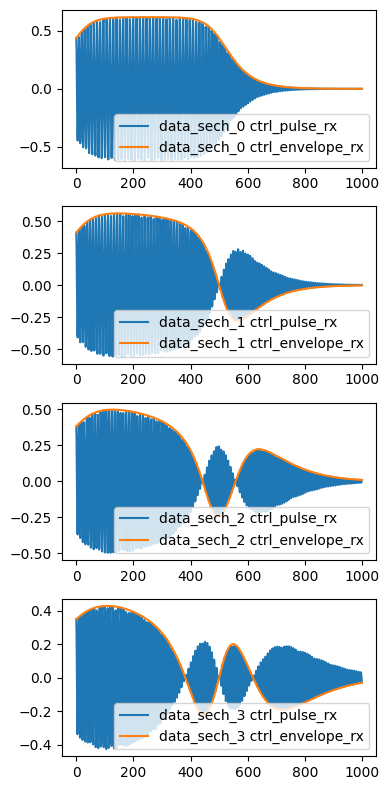

In [ ]:
analyzer.generate_control_pulse_rx(ctrl_pulse_path)

In [ ]:
def find_zero_point(envelope):
    diff_envelope = np.diff(envelope)
    sign_change = np.diff(np.sign(diff_envelope))

    inflection_points = np.where(sign_change == 2)[0] 
    
    return inflection_points

def flip_control_envelope(control_envelope, zero_points):
    flipped_envelope = control_envelope.copy()
    
    for i in range(len(zero_points)):  
        if i % 2 == 0:
            start = zero_points[i] + 1
            end = zero_points[i+1] + 1 if i+1 < len(zero_points) else len(control_envelope)
            flipped_envelope[start:end] *= -1  
    
    return flipped_envelope

def fit_waveform(time, data, x0=[2.5e-3,500], get_center=False, curve='sech', **kwargs):
    if curve=='sech':
        func = lambda x: x[0]/np.cosh(kwargs['kappa']*(time-x[1]))
        cost_func = lambda x: np.linalg.norm(x[0]/np.cosh(kwargs['kappa']*(time-x[1])) - data)
    elif curve=="sech_1":
        func = lambda x: np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*(time-x[1])/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_2":
        func = lambda x: np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**2-(np.pi/2/const)**2/3)/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    elif curve=="sech_3":
        func = lambda x: np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1])))
        cost_func = lambda x: np.linalg.norm(np.abs(x[0]*((time-x[1])**3-(7*(time-x[1])*(np.pi/(2*const))**2/5))/np.cosh(kwargs['kappa']*(time-x[1]))) - data)
    
    best_x = optimize.minimize(cost_func, x0=x0,method='Nelder-Mead',)
    # print(best_x)
    # print(f"center:{best_x.x}")
    if get_center==True:
        return best_x.x, func(best_x.x)
    return func(best_x.x)

def IQ_sym_(wave,time,start=0,stop=3000):
    wave_rev = np.flip(wave).conj()
    norm=np.sum(np.abs(wave)**2)**2
    m=0
    c=[]
    for i in range(len(wave)):
        wave_rev_i = np.roll(wave_rev, i)
        mult = wave*wave_rev_i
        mult_sum=np.sum(mult)
        cand = np.abs(mult_sum)**2
        c.append(cand/norm)
        if m<cand:
            m=cand
    # plt.plot(np.arange(len(wave)), c)
    return m/norm

def target_overlap(wave, time, curve='sech'):
    if curve=='sech':
        target = 1 / np.cosh(const * (time-time[-1]/2))
    elif curve=="sech_1":
        target = np.abs((time-time[-1]/2) / np.cosh(const * (time-time[-1]/2)))
    elif curve=="sech_2":
        target = np.abs(((time-time[-1]/2)**2-(np.pi/2/const)**2/3) / np.cosh(const * (time-time[-1]/2)))
    elif curve=="sech_3":
        target = np.abs(((time-time[-1]/2)**3-(7*(time-time[-1]/2)*(np.pi/(2*const))**2/5)) / np.cosh(const * (time-time[-1]/2)))
    norm1=np.sqrt(np.sum(np.abs(wave)**2) * (time[1]-time[0]))
    norm2 = np.sqrt(np.sum(np.abs(target)**2) * (time[1]-time[0]))
    m1_t = np.abs(wave / norm1)
    m2_t = target / norm2
    m_2t_star_rev = np.flip(m2_t).conj() 
    m=0
    for i in range(len(wave)):
        m_t_star_rev_i = np.roll(m_2t_star_rev, i)
        mult = m1_t * m_t_star_rev_i
        mult_sum=np.sum(mult) * (time[1] - time[0])
        cand = np.abs(mult_sum)**2
        if m<cand:
            m=cand
    return m

symmetry 0.8830465036926078, overlap 0.9949977439137664


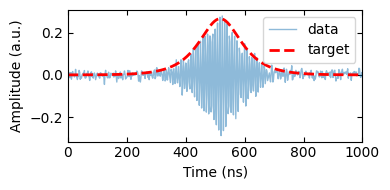

In [ ]:
from Analysis import (
    fourier_tr_padding, start_stop, lowpass, demodulate, load_note
)
from scipy import optimize
from datataking import search_datadict_miyamura
passing_band = 0.01
duration=1000
data_path = f"D:\\K_Sunada\\result\\{cd}"
corrected_result_dict = {
    "data_sech_0": dict(target_freq=9.35, date="2025-02-21", acquire_time="105455", form="sech_0"),
    # "data_sech_1": dict(target_freq=9.35, date="2025-02-21", acquire_time="105532", form="sech_1"),
    # "data_sech_2": dict(target_freq=9.35, date="2025-02-21", acquire_time="105609", form="sech_2"),
    # "data_sech_3": dict(target_freq=9.35, date="2025-02-21", acquire_time="105645", form="sech_3"),
}
for k, v in corrected_result_dict.items():
    fig = plt.figure(figsize=(4, 2))
    # ax = fig.add_subplot(1, 2, 1)
    ax2 = fig.add_subplot(1, 1, 1)
    target_freq = v["target_freq"]
    _, datadict = search_datadict_miyamura(data_path, v["date"], acquire_time=v["acquire_time"])
    time = datadict["time"]["values"].ravel()
    waveform = datadict["waveform"]["values"].ravel()
    time, waveform = start_stop(time, waveform, 0, duration)
    phase = np.angle(demodulate(time, waveform, readout_lo_freq-target_freq))
    # print(readout_lo_freq-target_freq)
    xfft, fourier = fourier_tr_padding(time, waveform)
    xfft, fourier = start_stop(xfft, fourier, xfft[0], 0)
    photon_freq = readout_lo_freq + xfft
    signal = 2 * lowpass(time, 
                        waveform * np.exp(2j*np.pi*(readout_lo_freq-target_freq)*time),
                        passing_band, 0.03, 0.1, 90) * np.exp(-1j*phase)
    zero_points = find_zero_point(envelope=np.abs(signal))
    flipped_env = flip_control_envelope(np.abs(signal), zero_points)
    res = fit_waveform(time, np.abs(signal), curve="sech", kappa=const)
    zero_points = find_zero_point(envelope=res)
    flipped_envelope = flip_control_envelope(res, zero_points)

    ax2.plot(time, 1000*waveform, "tab:blue", lw=1, alpha=0.5, label="data")
    # ax2.plot(time, -1000*flipped_env, "tab:blue",  lw=3, label="data")
    ax2.plot(time, 1000*flipped_envelope, "r--", lw=2, label="target", alpha=1)
    # ax2.plot(time, 1000*signal.real, "tab:blue", label="real", ls="--")
    # ax2.plot(time, 1000*signal.imag, "tab:blue",label="imag", ls="-.")
    ax2.set_xlabel("Time (ns)")
    ax2.set_ylabel("Amplitude (a.u.)")
    ax2.set_xlim(0, 1000)
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    ax2.tick_params(top='on',bottom='on',left='on',right='on',)
    print(f"symmetry {IQ_sym_(signal, time)}, overlap {target_overlap(signal, time, curve='sech')}")
plt.legend()
plt.tight_layout()
# plt.savefig('photon0.png', bbox_inches='tight')